## 1. Import Thư viện
dùng thêm `StandardScaler` để chuẩn hóa dữ liệu (Scaling) và `RandomForestRegressor` cho mô hình huấn luyện.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo không quan trọng

sns.set_style('whitegrid')

## 2. Đọc Dữ Liệu
Chúng ta sẽ sử dụng đường link raw chứa tập dữ liệu Medical Insurance chuẩn từ Kaggle để đọc trực tiếp.

In [2]:
# Đường link chứa dữ liệu Medical Insurance
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

# Đọc dữ liệu
df = pd.read_csv(url)

# Xem thử 5 dòng đầu
display(df.head())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Kiểm tra thông tin cơ bản
Bước này giúp chúng ta khám sức khỏe cho dữ liệu:
* `info()`: Xem kiểu dữ liệu của từng cột.
* Kiểm tra giá trị thiếu (Null) và dữ liệu bị trùng lặp (Duplicates).
* `describe()`: Thống kê các giá trị (Trung bình, lớn nhất, nhỏ nhất...) cho cả cột số và cột chữ.

In [4]:
print("--- THÔNG TIN CHUNG ---")
df.info()

print("\n--- KIỂM TRA DỮ LIỆU LỖI ---")
print("Số lượng dữ liệu thiếu (Null) ở mỗi cột:\n", df.isnull().sum())
print("Số dòng bị trùng lặp hoàn toàn: ", df.duplicated().sum())

# Xử lý: Xóa dòng trùng lặp (nếu có) để dữ liệu sạch hơn
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Đã xóa các dòng trùng lặp!")

print("\n--- THỐNG KÊ MÔ TẢ (Cột Số - Numerical) ---")
display(df.describe())

print("\n--- THỐNG KÊ MÔ TẢ (Cột Chữ - Categorical) ---")
display(df.describe(include=['O']))

--- THÔNG TIN CHUNG ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- KIỂM TRA DỮ LIỆU LỖI ---
Số lượng dữ liệu thiếu (Null) ở mỗi cột:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Số dòng bị trùng lặp hoàn toàn:  1
Đã xóa các dòng trùng lặp!

--- THỐNG KÊ MÔ TẢ (Cột Số - Numerical) ---


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010



--- THỐNG KÊ MÔ TẢ (Cột Chữ - Categorical) ---


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


## 4. EDA: Khám phá phân phối của biến Mục tiêu (Target)
Biến mục tiêu của chúng ta là `charges` (Chi phí bảo hiểm). Ta cần xem chi phí này phân bổ như thế nào (đa số là thấp hay cao).

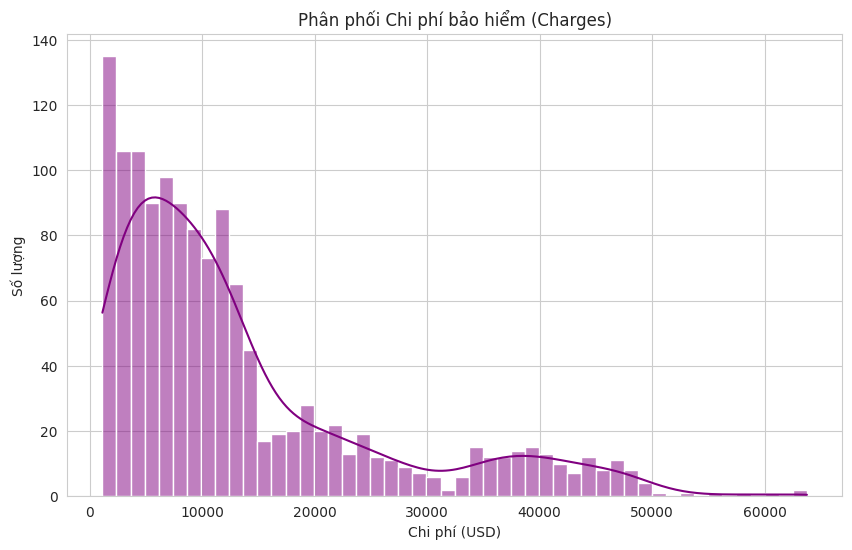

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='purple', bins=50)
plt.title('Phân phối Chi phí bảo hiểm (Charges)')
plt.xlabel('Chi phí (USD)')
plt.ylabel('Số lượng')
plt.show()

## 5. EDA: Mối quan hệ giữa các Đặc trưng (Features) và Chi phí
* **Biến phân loại (Categorical):** Dùng Boxplot để xem Giới tính, Việc hút thuốc, hay Vùng miền ảnh hưởng thế nào đến giá tiền.
* **Biến số (Numerical):** Dùng Scatterplot để xem Tuổi (Age) và Chỉ số cơ thể (BMI) làm tăng chi phí ra sao.

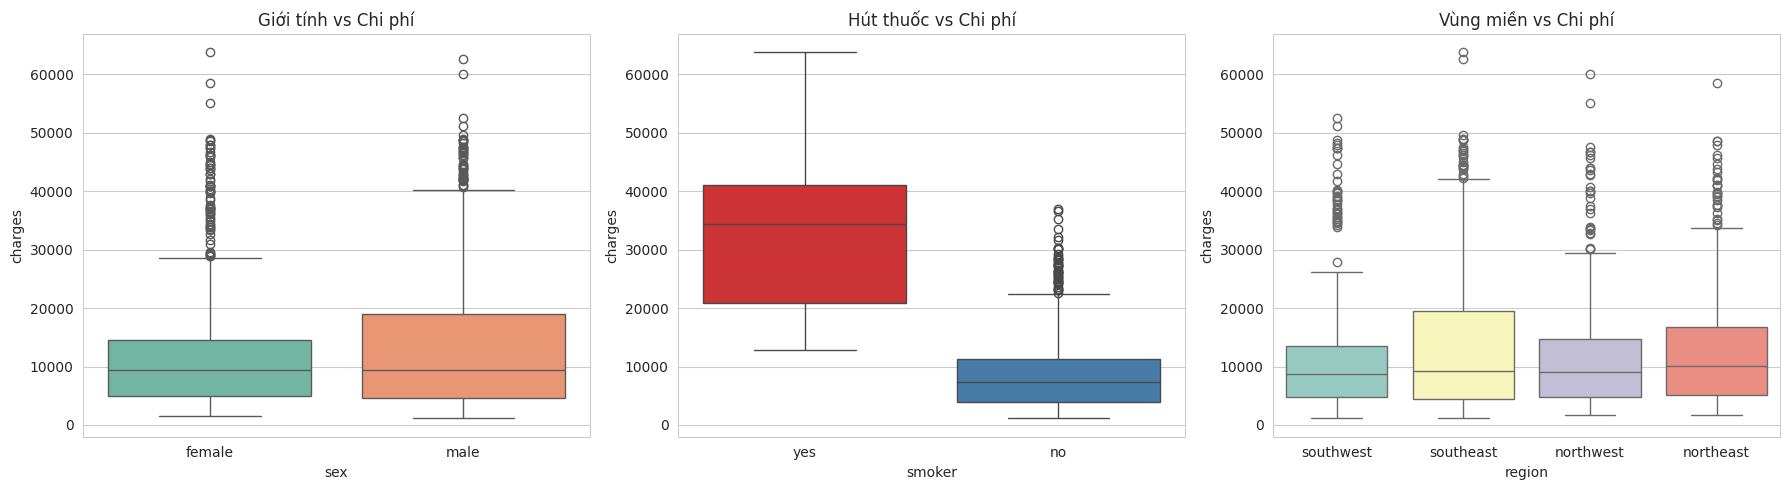

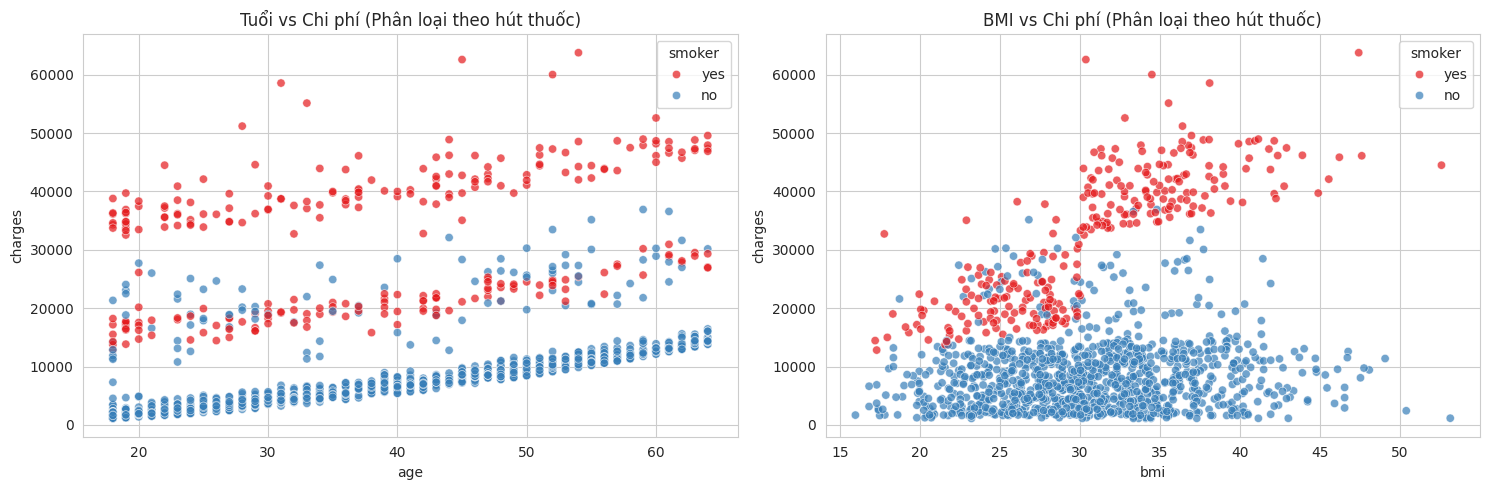

In [6]:
# 1. Biến phân loại -> Target (Categorical vs Target)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], x='sex', y='charges', data=df, palette='Set2')
axes[0].set_title('Giới tính vs Chi phí')

sns.boxplot(ax=axes[1], x='smoker', y='charges', data=df, palette='Set1')
axes[1].set_title('Hút thuốc vs Chi phí')

sns.boxplot(ax=axes[2], x='region', y='charges', data=df, palette='Set3')
axes[2].set_title('Vùng miền vs Chi phí')

plt.tight_layout()
plt.show()

# 2. Biến số -> Target (Numerical vs Target)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(ax=axes[0], x='age', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
axes[0].set_title('Tuổi vs Chi phí (Phân loại theo hút thuốc)')

sns.scatterplot(ax=axes[1], x='bmi', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
axes[1].set_title('BMI vs Chi phí (Phân loại theo hút thuốc)')

plt.tight_layout()
plt.show()

## 6. Tiền xử lý dữ liệu và Chia tập Train/Test
1. **Chuyển đổi dữ liệu chữ thành số:** Máy tính không hiểu "yes/no", ta dùng hàm `pd.get_dummies` để biến chúng thành các cột 0 và 1.
2. **Chia dữ liệu:** Theo yêu cầu, chia tập train/test tỉ lệ 80:20 và `random_state = 42`.
3. **Scaling Data (Chuẩn hóa dữ liệu):** Đưa các thang đo (ví dụ Age là vài chục, nhưng Charges là hàng chục ngàn) về cùng một hệ quy chiếu giúp mô hình học chính xác hơn. *Lưu ý: Chỉ fit (tính toán) scaler trên tập Train, sau đó áp dụng (transform) cho tập Test để tránh rò rỉ dữ liệu.*


In [7]:
# 1. Mã hóa One-Hot Encoding cho các cột chữ (sex, smoker, region)
# drop_first=True giúp tránh bẫy đa cộng tuyến (ví dụ: nam = 1 thì hiểu nữ = 0, không cần 2 cột)
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 2. Tách X (Đặc trưng) và y (Mục tiêu)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# 3. Chia tập Train/Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# 4. Scaling Data (Chuẩn hóa tập X)
scaler = StandardScaler()

# Tính toán trên tập train và chuẩn hóa
X_train_scaled = scaler.fit_transform(X_train)
# Chỉ áp dụng chuẩn hóa cho tập test
X_test_scaled = scaler.transform(X_test)

Kích thước tập Train: (1069, 8)
Kích thước tập Test: (268, 8)


## 7. Xây dựng và Huấn luyện mô hình
Mình chọn **Random Forest Regressor** cho bài toán này. Qua phân tích EDA ở trên, bạn có thể thấy biến 'smoker' tạo ra sự phân nhánh rất rõ rệt về chi phí (người hút thuốc chi phí vọt lên rất cao). Random Forest là dạng mô hình cây quyết định, nó xử lý sự phân nhánh này xuất sắc hơn rất nhiều so với mô hình hồi quy đường thẳng (Linear Regression), giúp bạn dễ dàng đạt điểm hiệu quả cực cao!

In [8]:
# Khởi tạo mô hình Random Forest
# n_estimators là số lượng cây quyết định trong rừng
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Huấn luyện mô hình trên tập Train đã được chuẩn hóa
model.fit(X_train_scaled, y_train)

# Dự đoán chi phí trên tập Test
y_pred = model.predict(X_test_scaled)

print("Đã huấn luyện và dự đoán xong!")

Đã huấn luyện và dự đoán xong!


## 8. Đánh giá chất lượng mô hình
Tính toán các độ đo bắt buộc: MSE, RMSE, và MAE để xem trung bình mô hình của chúng ta đoán lệch bao nhiêu đô-la.

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ---
Mean Squared Error (MSE)      : 22,372,575.46
Root Mean Squared Error (RMSE): 4,729.97
Mean Absolute Error (MAE)     : 2,663.33
Độ chính xác R-squared (R2)   : 0.8782


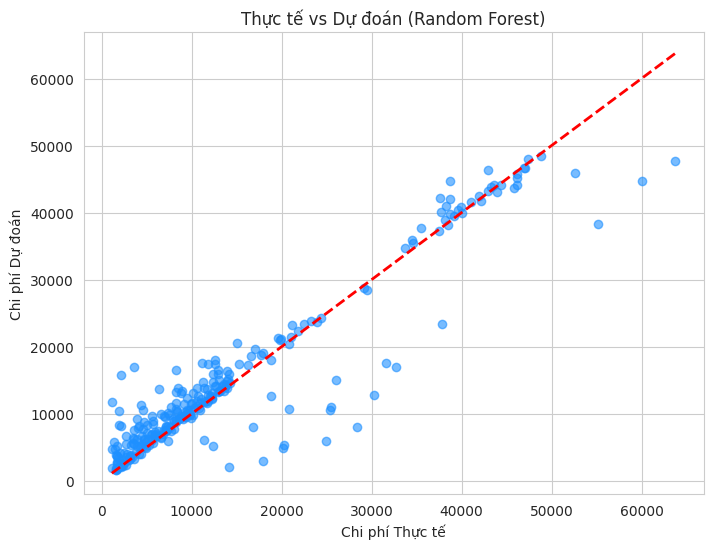

In [9]:
# Tính toán các chỉ số đánh giá
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred) # Thêm R2 để thấy % giải thích được của mô hình

print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST ---")
print(f"Mean Squared Error (MSE)      : {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE)     : {mae:,.2f}")
print(f"Độ chính xác R-squared (R2)   : {r2:,.4f}")

# Vẽ đồ thị so sánh (Bonus thêm để bạn dễ phân tích)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Chi phí Thực tế')
plt.ylabel('Chi phí Dự đoán')
plt.title('Thực tế vs Dự đoán (Random Forest)')
plt.show()